# Goal:

This notebook is part of a series of tests that we want to perform to make sure out reconstruction algorithm is working as expected.

After running 2Q-GST,even with infinite shots we obtained some MVE values that are not as expected. We would have liked to have virtually zero but instead got an MVE on random sequences of around $10^{-3}$ (and cost function of around $10^{-6}$). 

Now, we are trying for 1Q GST in hopes that we obtain significantly smaller values.

In [63]:
import jax.numpy as jnp
import numpy as np
from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
from mGST.utility_functions_comparisons import target_kraus_tensor_from_configuration, kraus_tensor_to_mgst, get_compressed_rep_from_mgst_output, get_compressed_perturbed_kraus_from_superop, get_compressed_perturbed_rep_from_mgst
from mGST.simulate import amplitude_damping_kraus_operators, get_initial_state_and_measurement, apply_single_superop_to_povm_tensor, apply_single_superop_to_state_matrix, run_optimization_workflow, diamond_norm_distances, average_and_std_mve, compute_mean_and_std
from mGST.gauge_analysis import max_num_parameters, min_num_parameters
from mGST.visualization import plot_cost_function, plot_mean_std_vs_x

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create gate set (target and noisy)

In [12]:
num_sequences = 100
num_shots = 1000
seq_len_list = [1, 8, 14]
num_qubits = 1
dim = 2 ** num_qubits
state_rank = dim # max
povm_rank = dim # max
backend = "iqmfakeapollo"

In [13]:
configuration = GSTConfiguration(
    qubit_layouts=[[0]],
    gate_set="1QXYI",
    num_circuits=num_sequences,
    shots=num_shots,
    rank=1,
)

kraus_tensor_target, gate_labels = target_kraus_tensor_from_configuration(configuration, backend)
# (num_gates, kraus_rank, dim_out, dim_in)
kraus_tensor_target.shape, gate_labels

((3, 1, 2, 2), {'[0]': {0: 'Idle:QB1', 1: 'Rx_pi_2:QB1', 2: 'Ry_pi_2:QB1'}})

In [14]:
# kraus operators for amplitude damping channel
noise_strength = 1e-4
ad_channel_2q = amplitude_damping_kraus_operators(gamma=noise_strength, num_qubits=num_qubits)

# NOTE: didn't do separate ones just for ease of contraction. Could do this for funsies.
# ad_channel_cz = amplitude_damping_kraus_operators(gamma=noise_strength_cz, num_qubits=2)
print(ad_channel_2q.shape) # (kraus_rank, dim_out, dim_in)

(2, 2, 2)


In [15]:
# prune the rank 1 of the unitary tensor for simplicity of contraction
gate_set_unitary_rank_3 = jnp.squeeze(kraus_tensor_target, axis=1) # (num_gates, dim_out, dim_in) 
# now let's combine them 
noisy_kraus_tensor = jnp.einsum('kij, ljm->lkim', ad_channel_2q, gate_set_unitary_rank_3)
noisy_kraus_tensor.shape # (num_gates, kraus_rank, dim_out, dim_in)

(3, 2, 2, 2)

In [24]:
num_gates, kraus_rank = noisy_kraus_tensor.shape[:2]
print(num_gates, kraus_rank)
# let's actually change it to max rank
kraus_rank = dim**2
print(kraus_rank)

3 2
4


In [25]:
# let's obtain the superoperator versions for all 3
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_target)
kraus_superop_noisy = kraus_tensor_to_mgst(noisy_kraus_tensor)
kraus_superop_ad_channel = kraus_tensor_to_mgst(ad_channel_2q.reshape((1, *ad_channel_2q.shape)))
assert (kraus_superop_ad_channel.shape == (1, dim**2, dim**2)) # (num_gates, dim_out*dim_out, dim_in*dim_in)
assert (kraus_superop_target.shape == kraus_superop_noisy.shape == (num_gates, dim**2, dim**2)) # (num_gates, dim_out*dim_out, dim_in*dim_in)

In [26]:
# now the povm and state
state_target_matrix, povm_target_tensor = get_initial_state_and_measurement(dim=dim)
state_target_matrix.shape, povm_target_tensor.shape # (dim, dim), (kraus_rank, dim_out, dim_in)

((2, 2), (2, 2, 2))

In [27]:
# now let's obtain their noisy versions by applying the superoperators to them
state_matrix_noisy = apply_single_superop_to_state_matrix(state_matrix=state_target_matrix, superop=kraus_superop_ad_channel)
povm_tensor_noisy = apply_single_superop_to_povm_tensor(povm_tensor=povm_target_tensor, superop=kraus_superop_ad_channel)

# Get compressed versions

In [28]:
state_vect_target = state_target_matrix.reshape(-1) # (dim*dim,)
povm_vect_target = povm_target_tensor.reshape(povm_target_tensor.shape[0], -1) # (kraus_rank, dim_out*dim_in)

state_vect_noisy = state_matrix_noisy.reshape(-1) # (dim*dim,)
povm_vect_noisy = povm_tensor_noisy.reshape(povm_tensor_noisy.shape[0], -1) # (kraus_rank, dim_out*dim_in)

print(state_vect_target.shape, povm_vect_target.shape)

(4,) (2, 4)


In [36]:
# first the target
kraus_tensor_target, povm_psd_target, state_psd_target = get_compressed_rep_from_mgst_output(kraus_superop_target, povm_vect_target, state_vect_target, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

# now the noisy versions for the simulation
kraus_tensor_noisy, povm_psd_noisy, state_psd_noisy = get_compressed_rep_from_mgst_output(kraus_superop_noisy, povm_vect_noisy, state_vect_noisy, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

print(kraus_tensor_target.shape, povm_psd_target.shape, state_psd_target.shape)
print(kraus_tensor_noisy.shape, povm_psd_noisy.shape, state_psd_noisy.shape)

(3, 4, 2, 2) (2, 2, 2) (2, 2)
(3, 4, 2, 2) (2, 2, 2) (2, 2)


# Initial tensors

Based on the results from the `2q_target` notebook, we only perturb the kraus tensor.

In [38]:
kraus_tensor_init_dict = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=kraus_rank, seed=42)
kraus_tensor_init = kraus_tensor_init_dict["kraus_tensor"]


povm_psd_init, state_psd_init = get_compressed_perturbed_rep_from_mgst(povm_vect_target, state_vect_target, rank_povm=povm_rank, rank_state=state_rank)

init_operators = {
    "kraus": kraus_tensor_init,
    "povm": povm_psd_init,
    "state": state_psd_init,
}

operators_psd_noisy={
    "kraus": kraus_tensor_noisy,
    "povm": povm_psd_noisy,
    "state": state_psd_noisy
}

true_superops={
    "kraus": kraus_superop_target,
    "povm": povm_vect_target,
    "state": state_vect_target
}

print(f"shapes: {[v.shape for v in init_operators.values()]}")
print(f"shapes: {[v.shape for v in operators_psd_noisy.values()]}")
print(f"shapes: {[v.shape for v in true_superops.values()]}")

shapes: [(3, 4, 2, 2), (2, 2, 2), (2, 2)]
shapes: [(3, 4, 2, 2), (2, 2, 2), (2, 2)]
shapes: [(3, 4, 4), (2, 4), (4,)]


# Optimization

## num. parameters

In [81]:
# what are the max and min number of parameters for this configuration?
upper_bound = max_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)
lower_bound = min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

print(f"For parameters: num_qubits={num_qubits}, num_gates={num_gates}, kraus_rank={kraus_rank}, state_rank={state_rank}, povm_rank={povm_rank}")
print(f"Upper bound: {upper_bound}, Lower bound: {lower_bound}")

For parameters: num_qubits=1, num_gates=3, kraus_rank=4, state_rank=2, povm_rank=2
Upper bound: 103, Lower bound: 39


In [39]:
optimization_results_100_seq = run_optimization_workflow(
    num_sequences=100,
    num_shots=num_shots,
    init_operators=init_operators,
    operators_psd_noisy=operators_psd_noisy,
    target_superops=true_superops,
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x

In [45]:
optimization_results_10_seq = run_optimization_workflow(
    num_sequences=10,
    num_shots=num_shots,
    init_operators=init_operators,
    operators_psd_noisy=operators_psd_noisy,
    target_superops=true_superops,
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 9.740810e-04. |r∇f(x)|: 3.162912e-03. Radius: 1.00e-01
TCG finished after: 3/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 1. f(x): 9.366959e-04. |r∇f(x)|: 3.859046e-05. Radius: 2.00e-01
TCG finished after: 2/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 1.46e-09
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 1.697666e-06
Optimization finished ✅. 
 Iters: 2. f(x): 9.366926e-04. |r∇f(x)|: 5.369569e-09. Radius: 2.00e-01. Rejections: 0

 🎯 [Povm] Relative change in cost function value: 3.74e-05. Target: 1.00e-05.
🚀 TR started for operat

In [58]:
optimization_results_200_seq = run_optimization_workflow(
    num_sequences=200,
    num_shots=num_shots,
    init_operators=init_operators,
    operators_psd_noisy=operators_psd_noisy,
    target_superops=true_superops,
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.281376e-03. |r∇f(x)|: 1.391444e-02. Radius: 1.00e-01
TCG finished after: 2/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 1.67e-05
---------------------------------------
TR Iteration: 1. f(x): 9.886415e-04. |r∇f(x)|: 9.231653e-06. Radius: 1.00e-01
TCG finished after: 4/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 1.067697e-08
Optimization finished ✅. 
 Iters: 2. f(x): 9.886414e-04. |r∇f(x)|: 1.485640e-10. Radius: 2.00e-01. Rejections: 0

 🎯 [Povm] Relative change in cost function value: 2.92e-04. Target: 1.00e-05.
🚀 TR started for operat

In [62]:
optimization_results_400_seq = run_optimization_workflow(
    num_sequences=400,
    num_shots=num_shots,
    init_operators=init_operators,
    operators_psd_noisy=operators_psd_noisy,
    target_superops=true_superops,
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.321443e-03. |r∇f(x)|: 1.484098e-02. Radius: 1.00e-01
TCG finished after: 2/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 1.33e-05
---------------------------------------
TR Iteration: 1. f(x): 9.881752e-04. |r∇f(x)|: 1.171657e-05. Radius: 1.00e-01
TCG finished after: 3/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 3.15e-11
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 2.122567e-09
Optimization finished ✅. 
 Iters: 2. f(x): 9.881750e-04. |r∇f(x)|: 3.150098e-11. Radius: 1.00e-01. Rejections: 0

 🎯 [Povm] Relative change in cost function value: 3.33e-04. Target: 1.00e-05.
🚀 TR star

# MVE and diamond distance

In [51]:
kraus_superop_noisy_np = np.array(kraus_superop_noisy)
num_runs = 10
length = 14
samples = 1000

In [77]:
superops_gauged_10_seq = optimization_results_10_seq["superops_gauged"]
kraus_superop_gauged_10_seq = superops_gauged_10_seq["kraus"]
indices_dict_10_seq = optimization_results_10_seq["indices_dict"]
probability_matrices_10_seq = optimization_results_10_seq["probability_matrices"]
cost_fn_10_seq = optimization_results_10_seq["cost_fn_history"]
time_10_seq = optimization_results_10_seq["times"]["optimization_time"]

diamond_distances_optimized_10_seq = diamond_norm_distances(superop1=kraus_superop_gauged_10_seq, superop2=kraus_superop_noisy_np)

mve_10_seq = average_and_std_mve(true_superops=true_superops, gst_superops=superops_gauged_10_seq, length=length, samples=samples, num_runs=num_runs)

mve_10_seq, diamond_distances_optimized_10_seq, time_10_seq

((Array(0.02614651, dtype=float64), Array(0.00075022, dtype=float64)),
 [0.018064999881861596, 0.02397570428261008, 0.006825608508576052],
 3.053032398223877)

In [54]:
superops_gauged_100_seq = optimization_results_100_seq["superops_gauged"]
kraus_superop_gauged_100_seq = superops_gauged_100_seq["kraus"]
indices_dict_100_seq = optimization_results_100_seq["indices_dict"]
probability_matrices_100_seq = optimization_results_100_seq["probability_matrices"]
cost_fn_100_seq = optimization_results_100_seq["cost_fn_history"]

diamond_distances_optimized_100_seq = diamond_norm_distances(superop1=kraus_superop_gauged_100_seq, superop2=kraus_superop_noisy_np)

mve_100_seq = average_and_std_mve(true_superops=true_superops, gst_superops=superops_gauged_100_seq, length=length, samples=samples, num_runs=num_runs)

mve_100_seq, diamond_distances_optimized_100_seq

((Array(0.00765951, dtype=float64), Array(0.00017612, dtype=float64)),
 [0.0027859196305506776, 0.006169021585669973, 0.003997882369950502])

In [78]:
time_100_seq = 2*60 + 6.8

In [75]:
superops_gauged_200_seq = optimization_results_200_seq["superops_gauged"]
kraus_superop_gauged_200_seq = superops_gauged_200_seq["kraus"]
indices_dict_200_seq = optimization_results_200_seq["indices_dict"]
probability_matrices_200_seq = optimization_results_200_seq["probability_matrices"]
cost_fn_200_seq = optimization_results_200_seq["cost_fn_history"]
time_200_seq = optimization_results_200_seq["times"]["optimization_time"]

diamond_distances_optimized_200_seq = diamond_norm_distances(superop1=kraus_superop_gauged_200_seq, superop2=kraus_superop_noisy_np)

mve_200_seq = average_and_std_mve(true_superops=true_superops, gst_superops=superops_gauged_200_seq, length=length, samples=samples, num_runs=num_runs)

mve_200_seq, diamond_distances_optimized_200_seq

((Array(0.00499001, dtype=float64), Array(0.00013066, dtype=float64)),
 [0.0018162555816971953, 0.00213628618351497, 0.001804075856978823])

In [76]:
superops_gauged_400_seq = optimization_results_400_seq["superops_gauged"]
kraus_superop_gauged_400_seq = superops_gauged_400_seq["kraus"]
indices_dict_400_seq = optimization_results_400_seq["indices_dict"]
probability_matrices_400_seq = optimization_results_400_seq["probability_matrices"]
cost_fn_400_seq = optimization_results_400_seq["cost_fn_history"]
time_400_seq = optimization_results_400_seq["times"]["optimization_time"]

diamond_distances_optimized_400_seq = diamond_norm_distances(superop1=kraus_superop_gauged_400_seq, superop2=kraus_superop_noisy_np)

mve_400_seq = average_and_std_mve(true_superops=true_superops, gst_superops=superops_gauged_400_seq, length=length, samples=samples, num_runs=num_runs)

mve_400_seq, diamond_distances_optimized_400_seq

((Array(0.00267816, dtype=float64), Array(7.52941219e-05, dtype=float64)),
 [0.0018142227135017998, 0.0008640506332579967, 0.0006417165062291928])

# Visualization

In [65]:
mve_results_over_sequences = [mve_10_seq, mve_100_seq, mve_200_seq, mve_400_seq]
num_sequences_list = [10, 100, 200, 400]

mve_results_dict = {str(num_seq): {"mean": mean, "std": std} for num_seq, (mean, std) in zip(num_sequences_list, mve_results_over_sequences)}

In [66]:
diamond_distances_vs_sequences = [diamond_distances_optimized_10_seq, diamond_distances_optimized_100_seq, diamond_distances_optimized_200_seq, diamond_distances_optimized_400_seq]

mean_std_diamond_distances = [compute_mean_and_std(jnp.array(distances)) for distances in diamond_distances_vs_sequences]

distances_dict = {str(num_seq): {"mean": mean, "std": std} for num_seq, (mean, std) in zip(num_sequences_list, mean_std_diamond_distances)}
distances_dict

{'10': {'mean': Array(0.01628877, dtype=float64),
  'std': Array(0.00711326, dtype=float64)},
 '100': {'mean': Array(0.00431761, dtype=float64),
  'std': Array(0.00139953, dtype=float64)},
 '200': {'mean': Array(0.00191887, dtype=float64),
  'std': Array(0.00015382, dtype=float64)},
 '400': {'mean': Array(0.00110666, dtype=float64),
  'std': Array(0.00050849, dtype=float64)}}

2026-07-14 10:57:38,129 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-07-14 10:57:38,175 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode


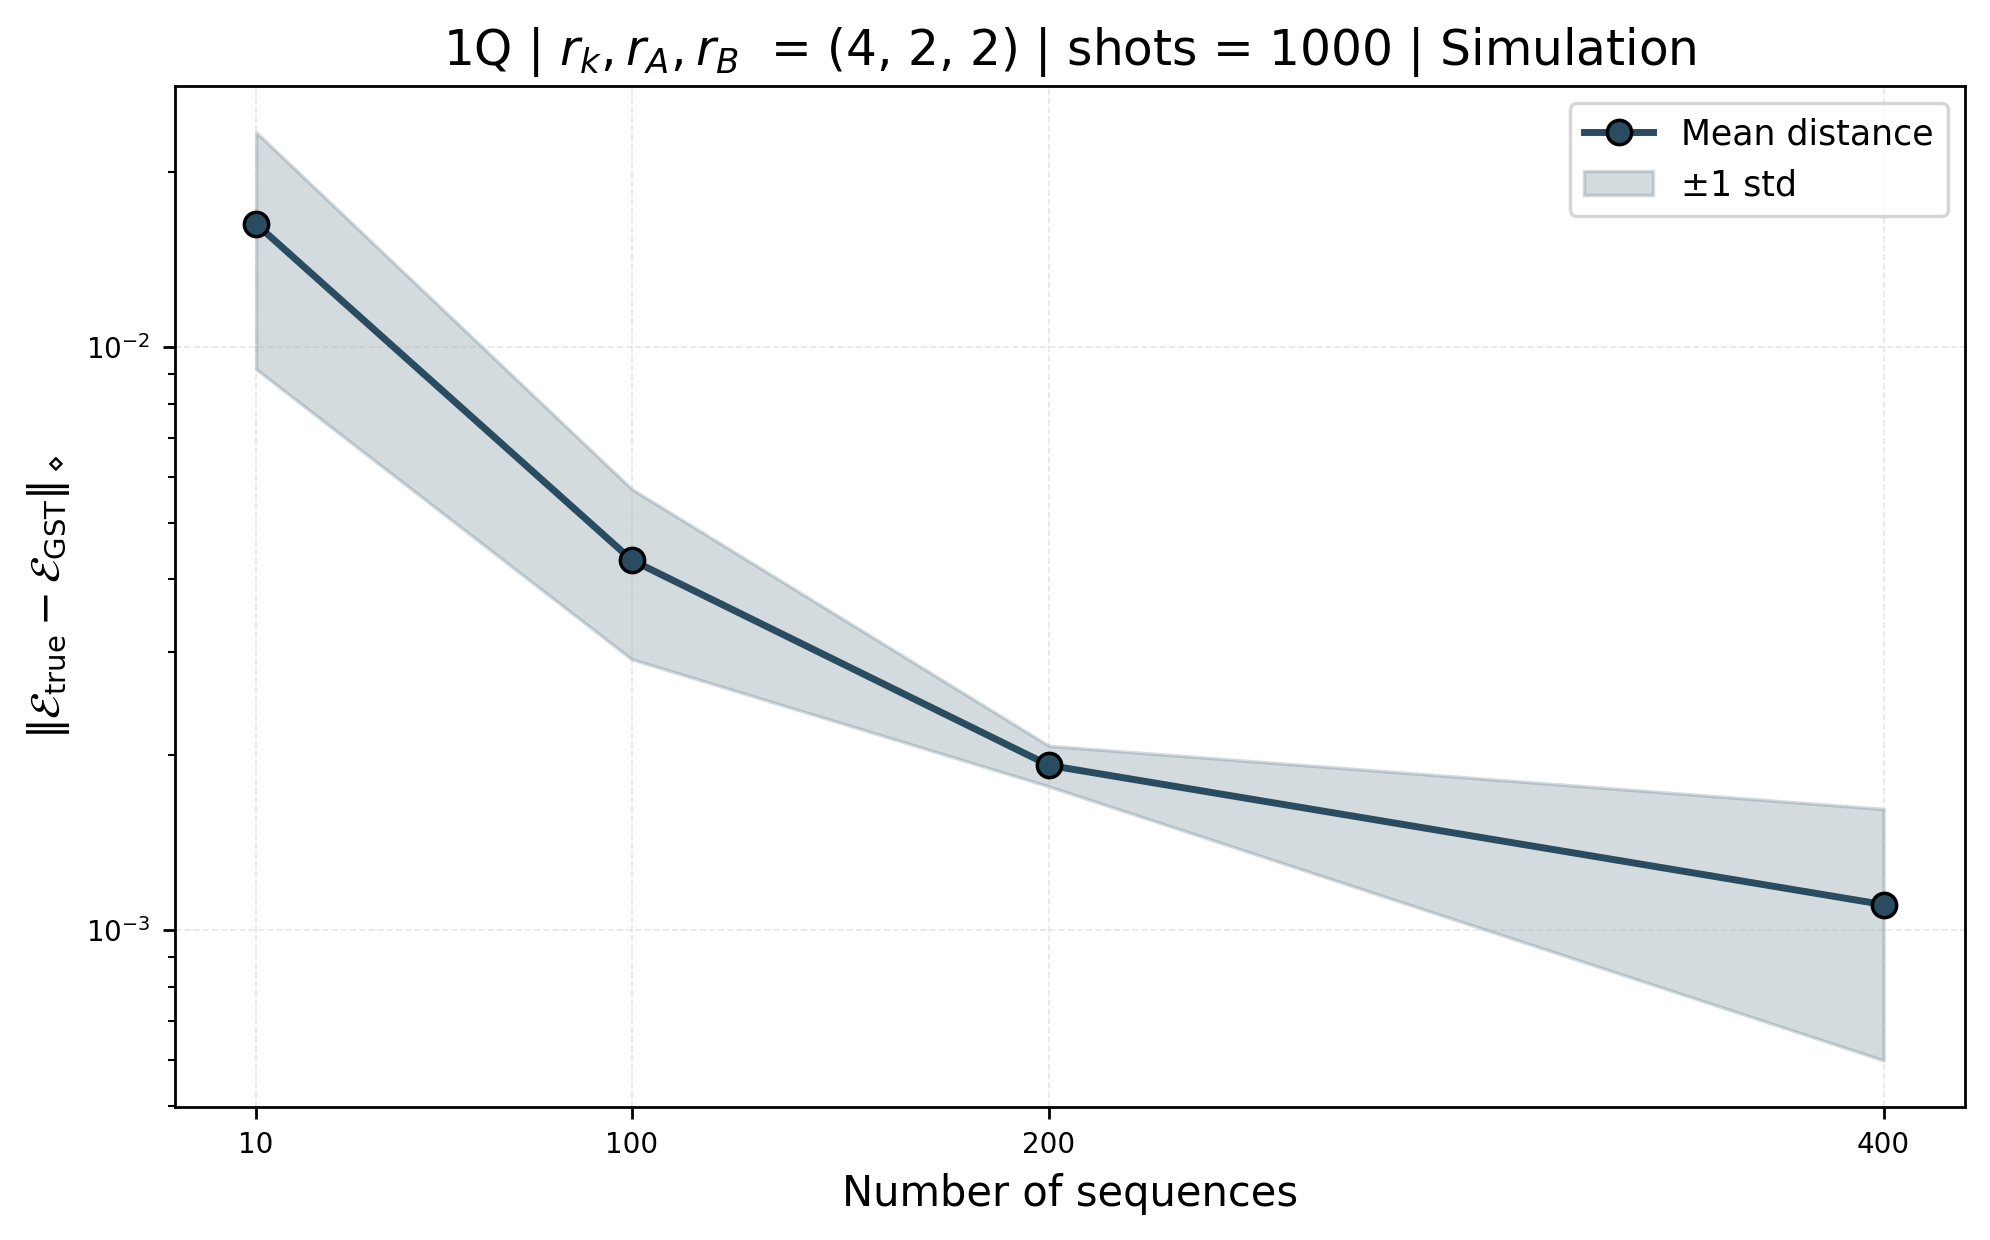

In [70]:
figure = plot_mean_std_vs_x(
    distances_dict,
    title=rf"{num_qubits}Q | $r_k, r_A, r_B$  = {kraus_rank, povm_rank, state_rank} | shots = {num_shots} | Simulation",
    ylabel=r"$\| \mathcal{E}_{\text{true}} - \mathcal{E}_{\text{GST}} \|_\diamond$",
    use_log_scale=True,
    # comparison_value = (rf"$\infty$ shots at 1200 sequences: {diamond_distance_mean_std_infinite_shots[0]:.3f}", diamond_distance_mean_std_infinite_shots[0]),
)

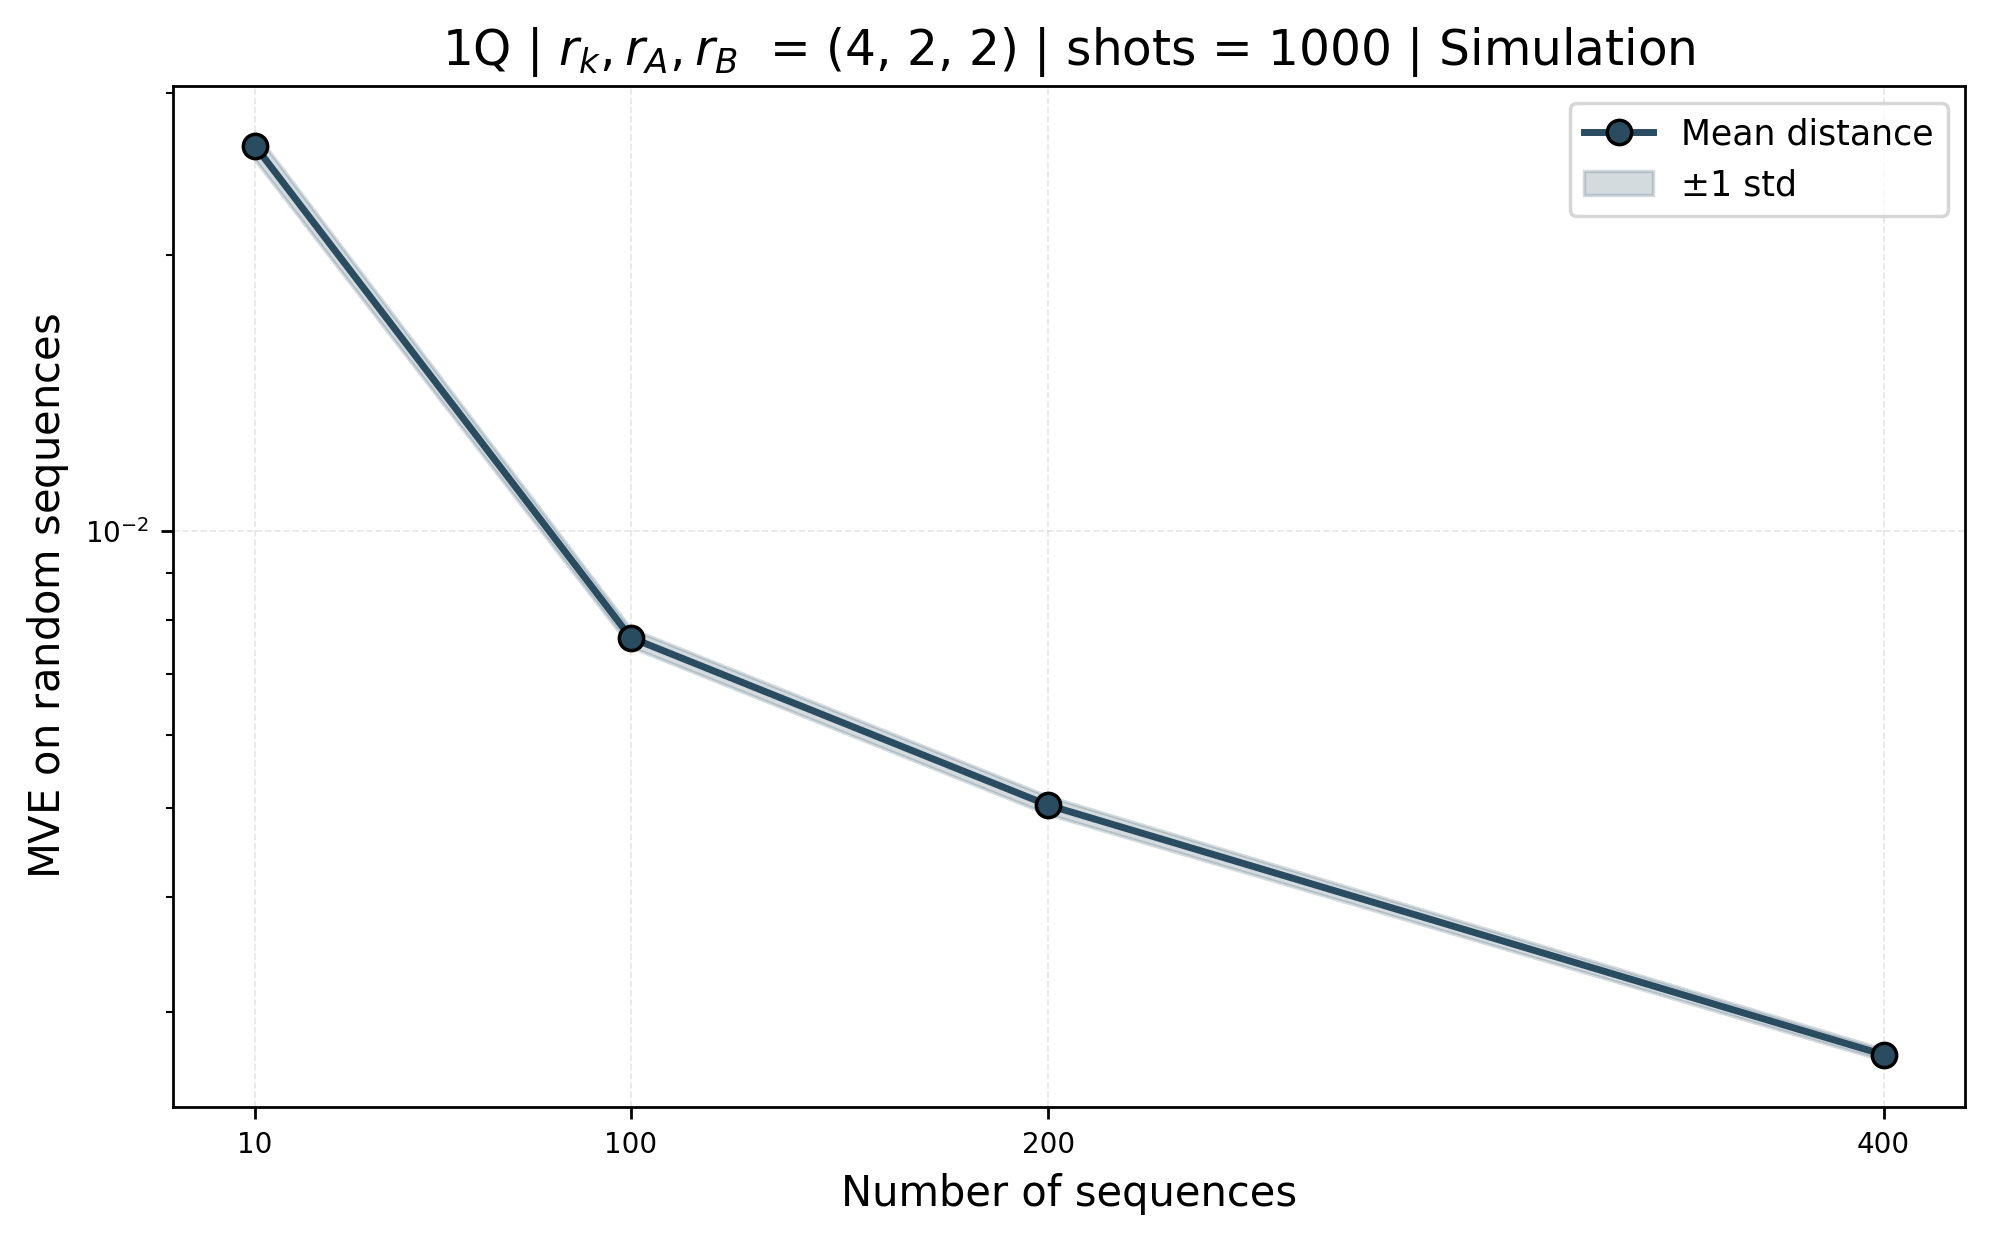

In [69]:
figure = plot_mean_std_vs_x(
    mve_results_dict,
    title=rf"{num_qubits}Q | $r_k, r_A, r_B$  = {kraus_rank, povm_rank, state_rank} | shots = {num_shots} | Simulation",
    ylabel=r"$\text{MVE}$ on random sequences",
    use_log_scale=True,
    # comparison_value = (rf"$\infty$ shots at 1200 sequences: {error_infinite_shots[0]:.3f}", error_infinite_shots[0]),
)

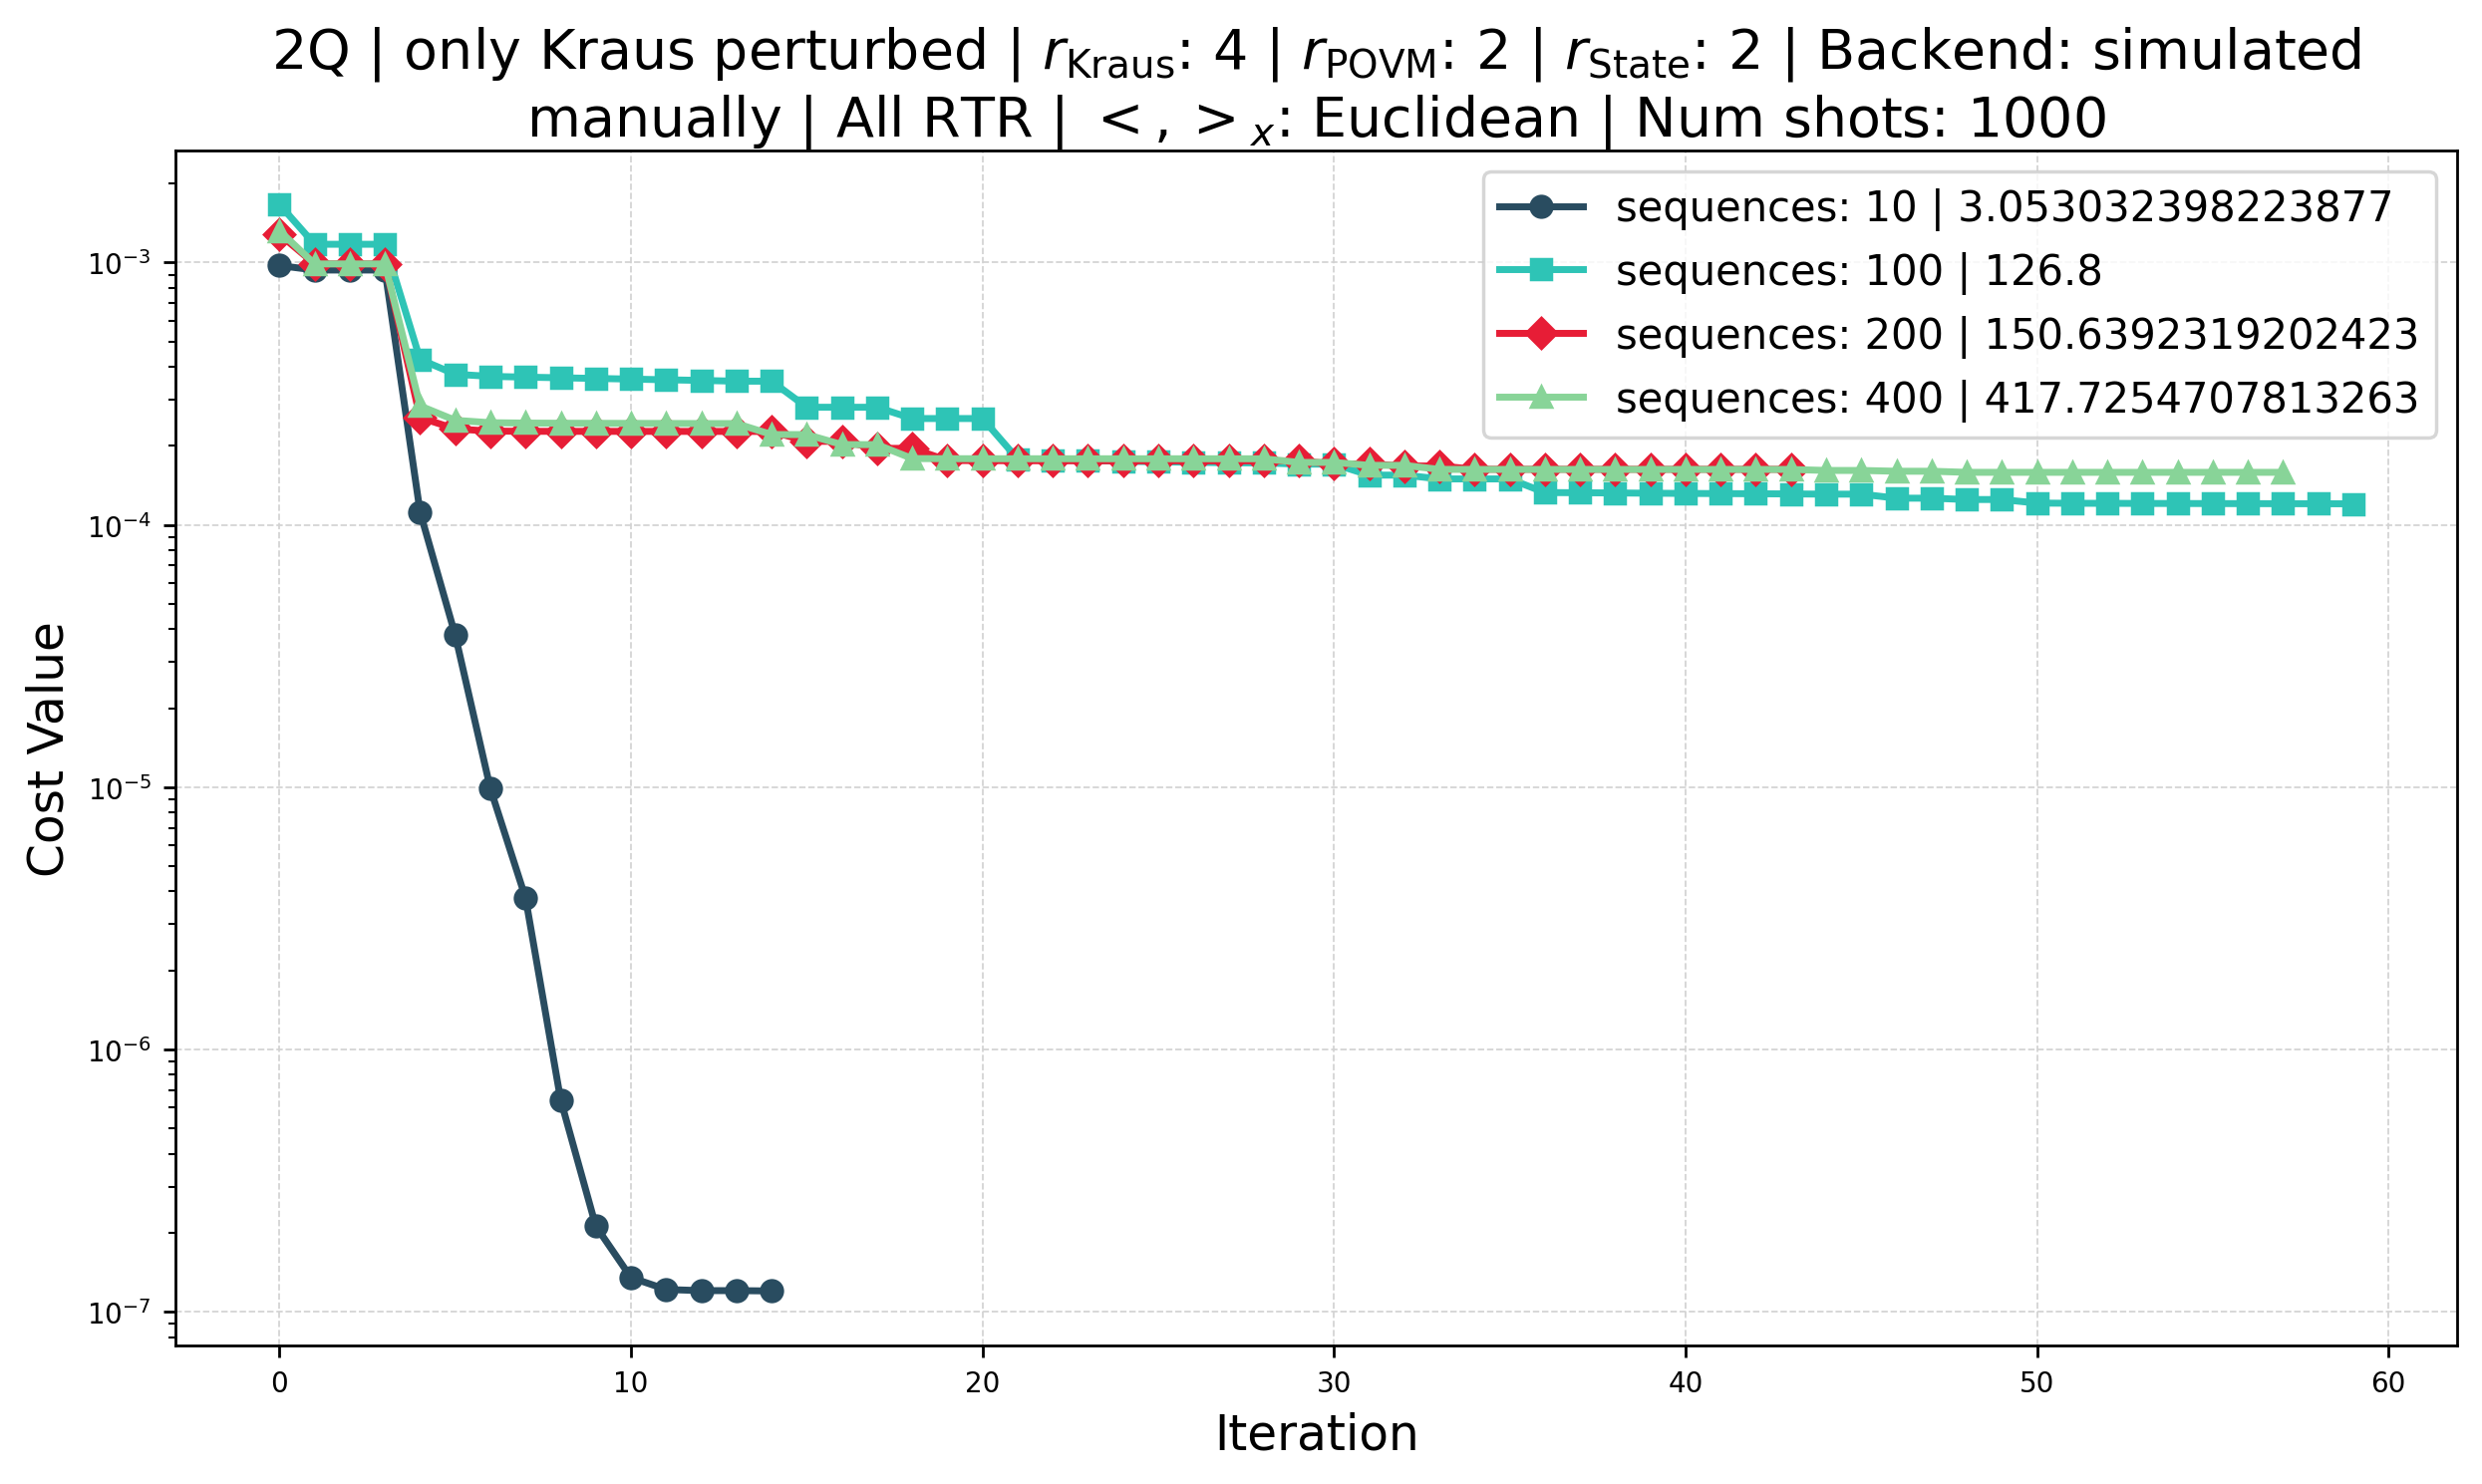

In [79]:
cost_fn_lists = [
    cost_fn_10_seq,
    cost_fn_100_seq,
    cost_fn_200_seq,
    cost_fn_400_seq,
]

times = [
    time_10_seq,
    time_100_seq,
    time_200_seq,
    time_400_seq,
]


labels_cost_fns = [f"sequences: {num_sequences} | {time}" for num_sequences, time in zip(num_sequences_list, times)]

title_cost_fn = rf"2Q | only Kraus perturbed | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Backend: simulated manually | All RTR | $<,>_x$: Euclidean | Num shots: {num_shots}"

plot_cost_function(cost_fn_lists, title=title_cost_fn, labels=labels_cost_fns, comparison_yline=None)